## Regresión Lineal Simple

La regresión lineal simple es un método estadístico que permite estudiar y modelar la relación entre dos variables continuas: una variable dependiente y una variable independiente.

### Modelo de Regresión Lineal

El modelo de regresión lineal adopta la forma `y = a + bx + e`, donde:

- `y` es la variable dependiente.
- `x` es la variable independiente.
- `a` es la intersección con el eje Y.
- `b` es la pendiente de la recta de regresión.
- `e` representa el error aleatorio o residuo.

En forma matricial `Y = Ax + E`

### Método de los Mínimos Cuadrados

Este método estima los parámetros `a` y `b` minimizando la suma de los cuadrados de los residuos.

### Ecuaciones Normales

Las ecuaciones normales son una forma de calcular analíticamente los parámetros `a` y `b` que minimizan la suma de los cuadrados de los residuos. Se obtienen al derivar la función de coste respecto a `a` y `b` y igualando a cero para encontrar los puntos donde la pendiente es cero (mínimos). El sistema de ecuaciones resultante se puede resolver para obtener los valores óptimos de los parámetros.


## 1. Generación de datos sintéticos

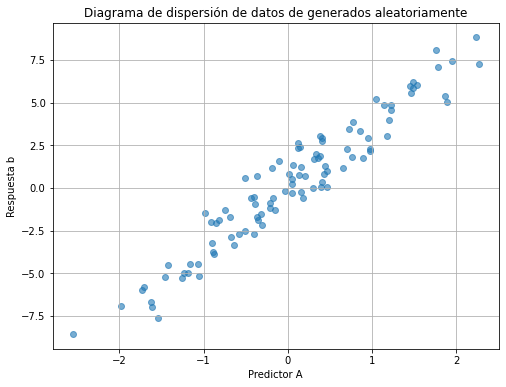

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Establecer la semilla aleatoria para reproducibilidad
np.random.seed(0)

# Número de observaciones
m = 100

# Característica/predictor
A = np.random.randn(m, 1)

# Respuestas/observaciones con algo de ruido
b = 3.5 * A.flatten() + np.random.randn(m)

# Trazar los datos
plt.figure(figsize=(8, 6))
plt.scatter(A, b, alpha=0.6)
plt.title('Diagrama de dispersión de datos de generados aleatoriamente')
plt.xlabel('Predictor A')
plt.ylabel('Respuesta b')
plt.grid(True)

# Mostrar el gráfico
plt.show()


## 2. Resolución por ecuaciones normales

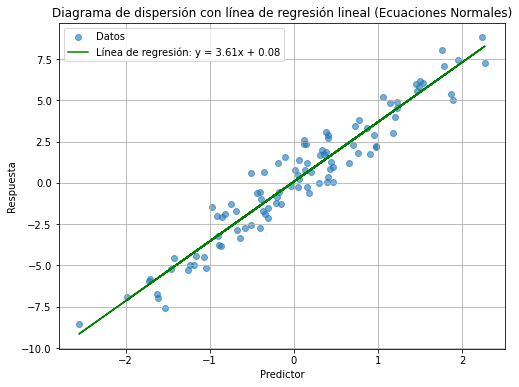

Los parámetros de la recta son: [0.07515309 3.61469843]
La norma de los residuos son:  10.28188627728701


In [2]:
# Agregando una columna de unos a la matriz de características para la intersección
A_unos = np.hstack([np.ones((m, 1)), A])

# Calculando los parámetros usando ecuaciones normales theta = (A.T * A)^(-1) * A.T * b
# Donde theta son los parámetros [intersección, pendiente]
theta_optimos = np.linalg.inv(A_unos.T.dot(A_unos)).dot(A_unos.T).dot(b)

# Extrayendo la pendiente y la intersección
pendiente_ne = theta_optimos[1]
interseccion_ne = theta_optimos[0]

# Trazando los datos y la línea de regresión
plt.figure(figsize=(8, 6))
plt.scatter(A, b, alpha=0.6, label='Datos')
plt.plot(A, A_unos.dot(theta_optimos), color='green', label=f'Línea de regresión: y = {pendiente_ne:.2f}x + {interseccion_ne:.2f}')
plt.title('Diagrama de dispersión con línea de regresión lineal (Ecuaciones Normales)')
plt.xlabel('Predictor')
plt.ylabel('Respuesta')
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

b_predicho_ne = A_unos.dot(theta_optimos)
residuos = b - b_predicho_ne

print(f"Los parámetros de la recta son: {theta_optimos}")
print("La norma de los residuos son: ", np.linalg.norm(residuos, ord=2))


## 3. Mínimos cuadrados como problema de optimización convexa

Reformulamos con la notación estándar de un problema de optimización, pasando de $Y = A\boldsymbol{x} + \boldsymbol{\epsilon}$ a la expresión:

\begin{array}{ll}
\min   & \|Ax - b\|_2^2.
\end{array}

In [3]:
# Define and solve the CVXPY problem.
import cvxpy as cp
x = cp.Variable(2)
cost = cp.sum_squares(A_unos @ x - b)

Evaluamos que la función sea convexa

In [4]:
print(cost.is_convex())

True


In [5]:
prob = cp.Problem(cp.Minimize(cost))
prob.solve()

# Print result.
print("El valor óptimo de la función es: ", prob.value)
print(f"El x óptimo es: {x.value}")
print("La norma-2 de los residuos es: ", cp.norm(A_unos @ x - b, p=2).value)

El valor óptimo de la función es:  105.71718541906291
El x óptimo es: [0.07515309 3.61469843]
La norma-2 de los residuos es:  10.28188627728701


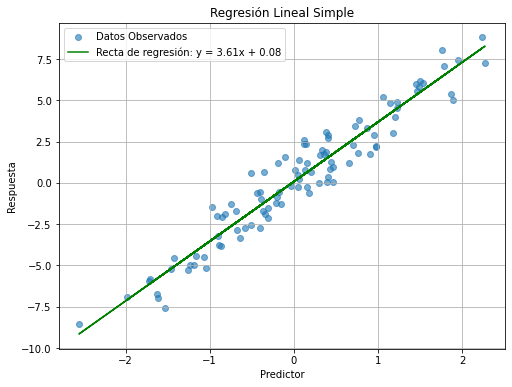

In [6]:
# Graficar los datos y la recta de regresión
plt.figure(figsize=(8, 6))
plt.scatter(A, b, alpha=0.6, label='Datos Observados')
plt.plot(A, A_unos.dot(x.value), color='green', label=f'Recta de regresión: y = {x.value[1]:.2f}x + {x.value[0]:.2f}')
plt.xlabel('Predictor')
plt.ylabel('Respuesta')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.grid(True)
plt.show()